In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

## Bài 1:

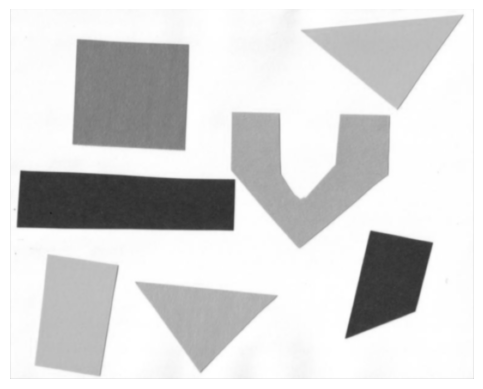

In [ ]:
image_path = "/content/ames1.jpg"
ames = cv2.imread(image_path)
plt.imshow(cv2.cvtColor(ames, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

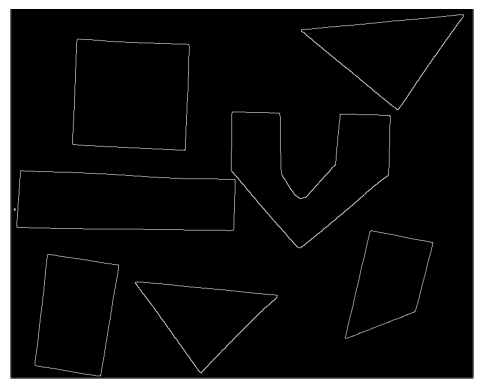

In [ ]:
edges_ames1 = cv2.Canny(ames, 50, 150)
plt.imshow(edges_ames1, cmap='gray')
plt.axis('off')
plt.show()

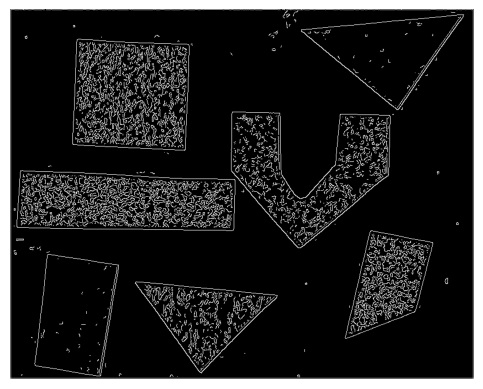

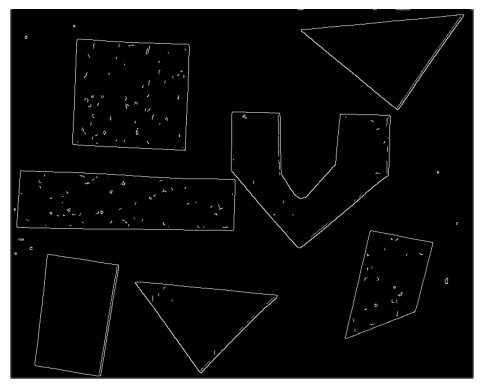

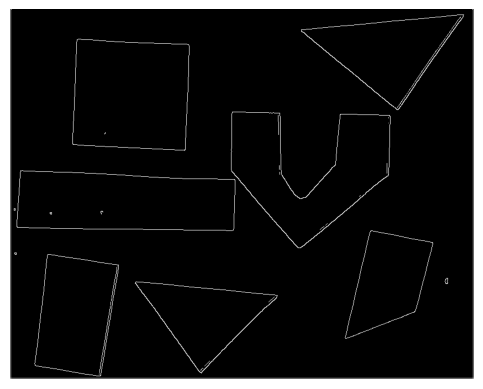

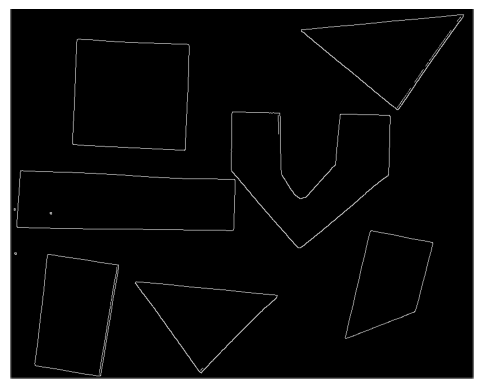

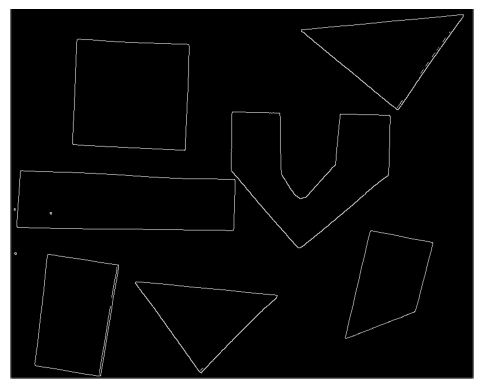

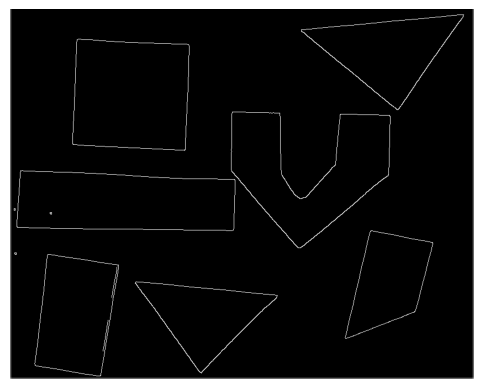

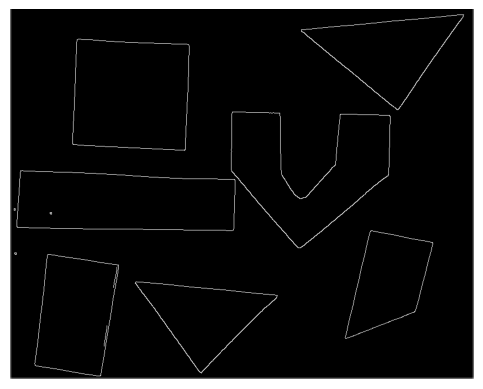

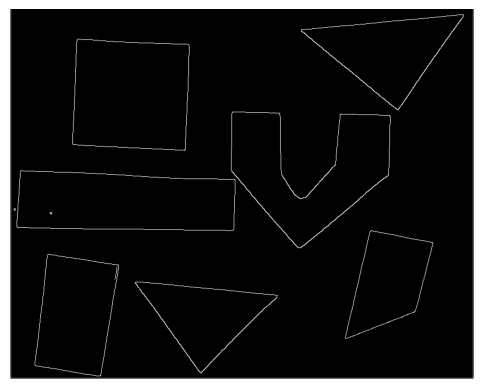

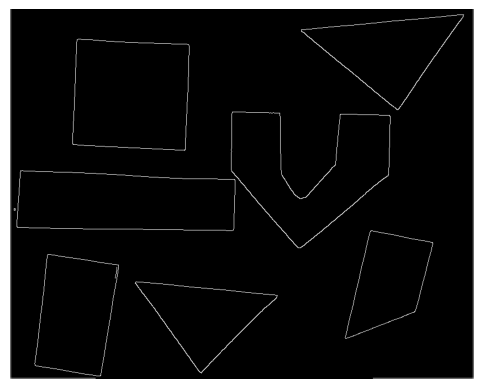

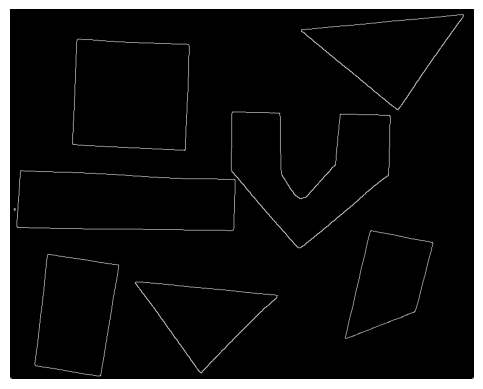

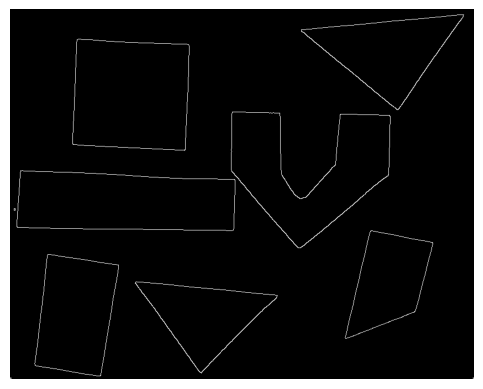

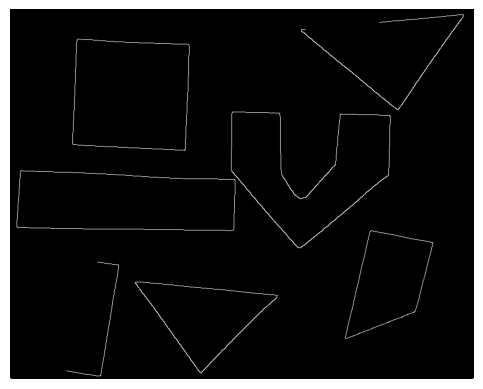

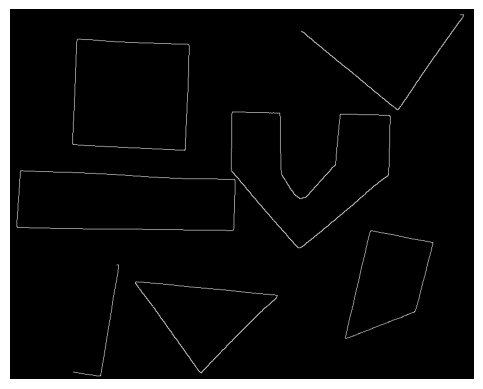

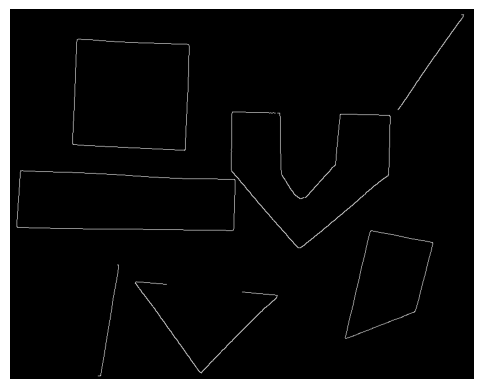

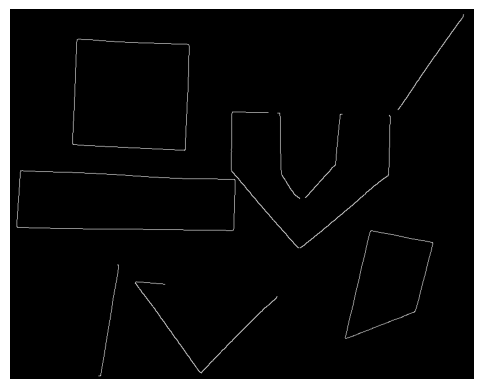

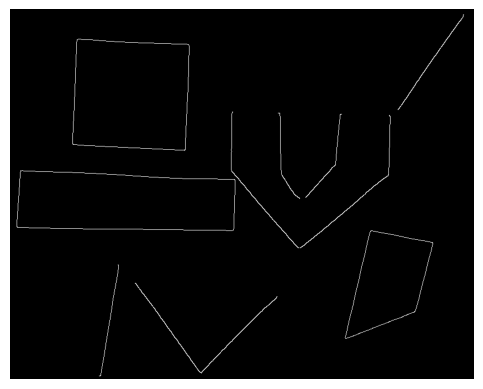

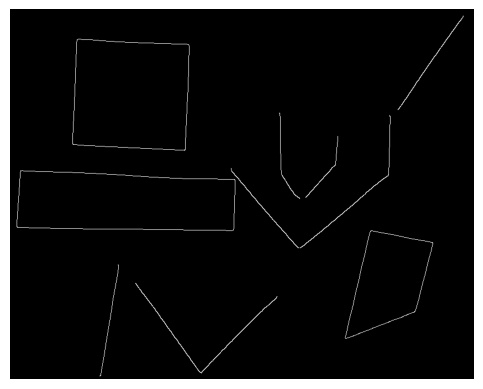

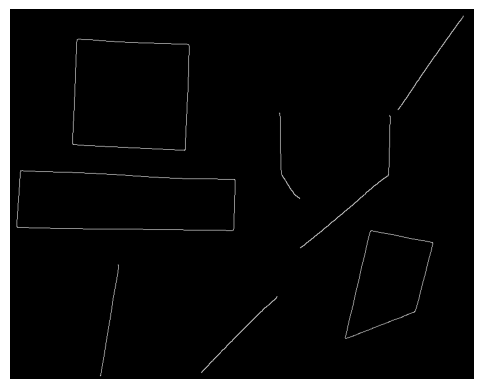

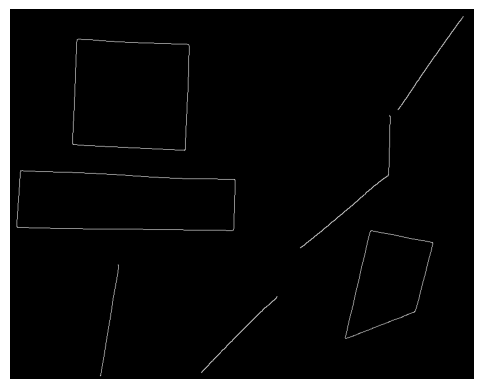

In [ ]:
for i in range(10,200,10):
  plt.imshow(cv2.Canny(ames, i, 1.5*i),cmap="gray")
  plt.axis('off')
  plt.show()

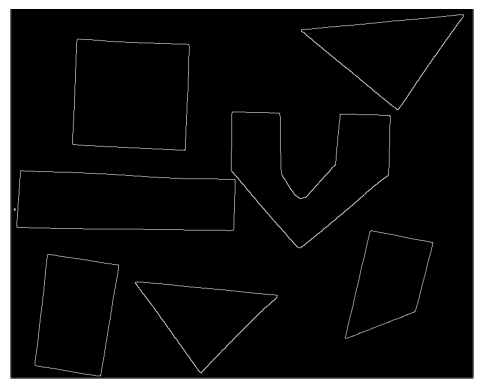

In [ ]:
edge = cv2.Canny(ames, 50, 150)
plt.imshow(edge,cmap="gray")
plt.axis('off')
plt.show()

In [ ]:
lines = cv2.HoughLinesP(edge, 1, np.pi/180, 50, minLineLength=50, maxLineGap=5)
lines.shape


(46, 1, 4)

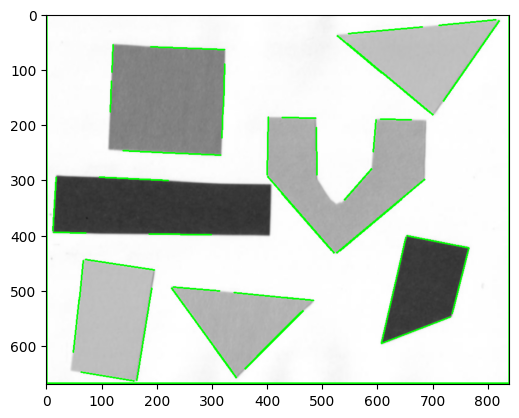

In [ ]:
for line in lines:
  x1, y1, x2, y2 = line[0]
  cp_ams = cv2.line(ames, (x1, y1), (x2, y2), (0, 255, 0), 2)
plt.imshow(cp_ams)

## Bài 2:

In [ ]:
img1 = cv2.imread("/content/t_img.png", 0)

In [ ]:
def add_gaussian_noise(image, mean=0, sigma=10):
    noise = np.random.normal(mean, sigma, image.shape).astype(np.float32)
    noisy_image = image.astype(np.float32) + noise
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
    return noisy_image

In [ ]:
list_sigma = [0,1,2,5,10,20,30,40,100,200,300,400]

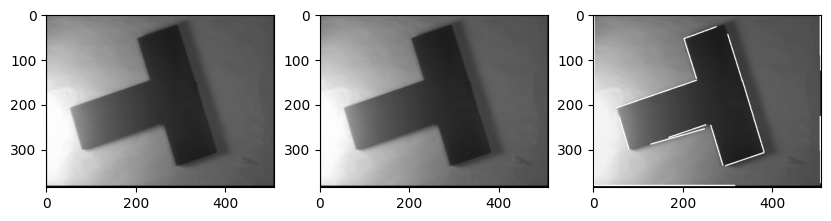

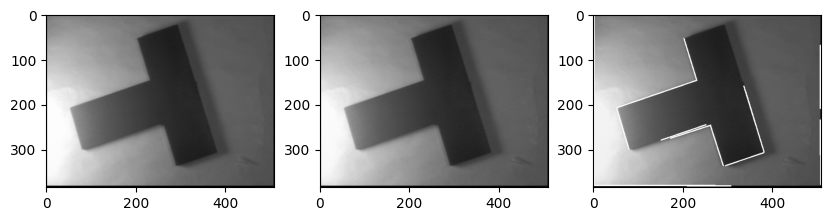

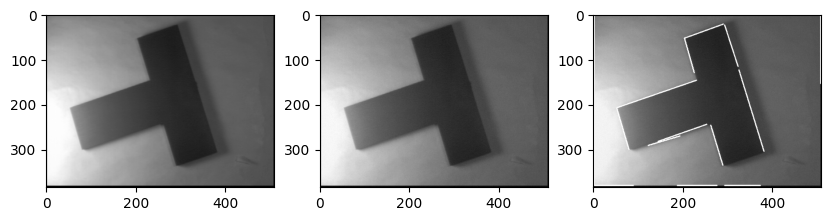

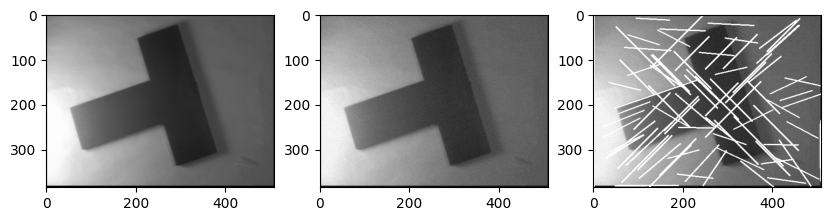

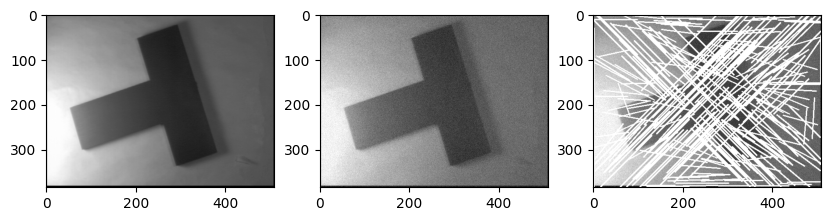

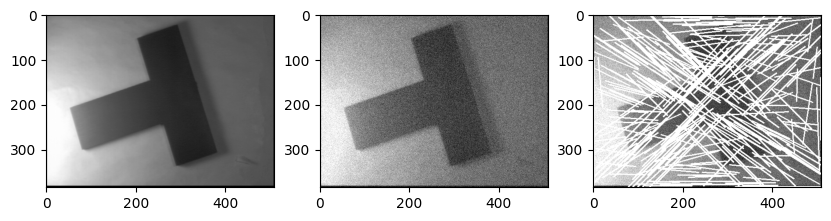

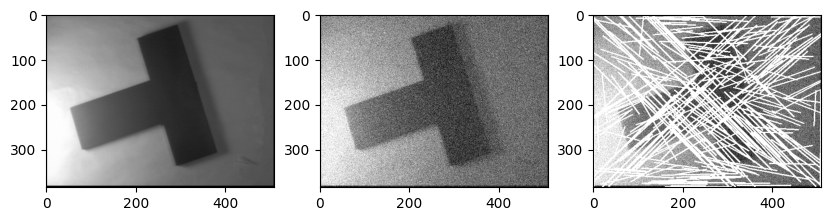

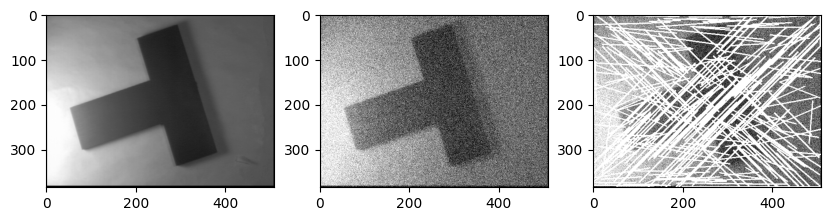

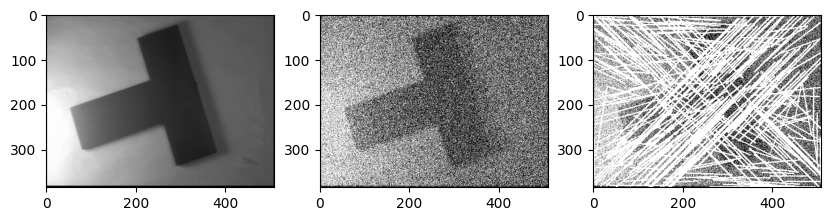

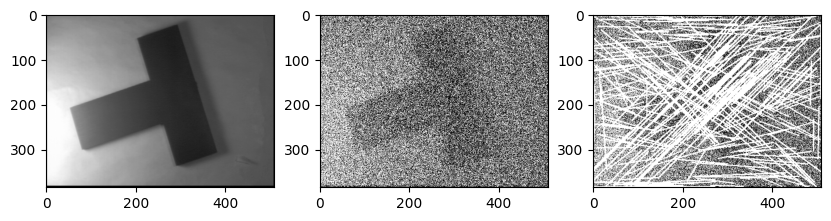

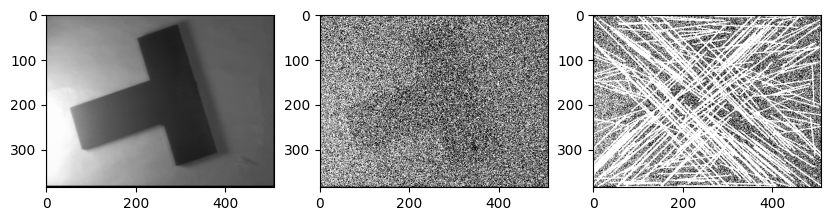

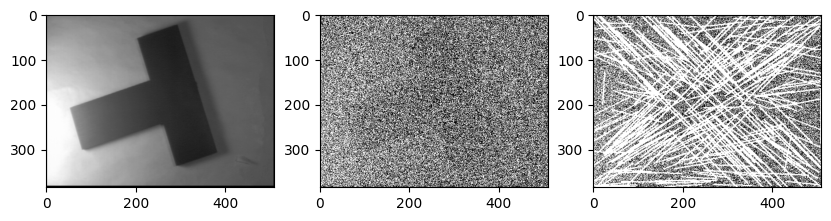

In [ ]:
for sigma in list_sigma:
  noisy = add_gaussian_noise(img1, sigma=sigma)
  edges = cv2.Canny(noisy, 20, 50)
  lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 50, minLineLength = 70, maxLineGap=5)
  fig, axis = plt.subplots(1, 3, figsize=(10, 5))
  axis[0].imshow(img1, cmap='gray')
  axis[1].imshow(noisy, cmap='gray')
  cp = noisy.copy()
  for line in lines:
    x1, y1, x2, y2 = line[0]
    cp_ams = cv2.line(cp, (x1, y1), (x2, y2), (255, 0, 0), 2)
  axis[2].imshow(cp_ams, cmap='gray')
  plt.show()

## Bài 3:

In [ ]:
img = cv2.imread("/content/coin.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [ ]:
gray_blurred = cv2.GaussianBlur(gray, (9, 9), 2)

circle = cv2.HoughCircles(
    gray_blurred,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist = 20,
    param1=200,
    param2=40,
    minRadius=10,
    maxRadius=100
)
circle

array([[[275.40002 , 245.40001 ,  34.      ],
        [342.6     ,  47.4     ,  26.08    ],
        [101.4     , 243.00002 ,  23.08    ],
        [437.40002 ,  94.200005,  21.04    ],
        [210.6     , 240.6     ,  27.160002],
        [124.200005, 142.20001 ,  24.400002],
        [291.      , 186.6     ,  22.48    ],
        [341.40002 , 141.      ,  25.      ],
        [105.00001 ,  93.      ,  24.52    ],
        [292.2     ,  46.2     ,  20.8     ],
        [385.80002 , 187.8     ,  18.28    ],
        [155.40001 , 244.20001 ,  27.28    ],
        [469.80002 , 144.6     ,  19.720001],
        [341.40002 , 190.20001 ,  21.880001],
        [292.2     , 138.6     ,  21.52    ],
        [ 51.000004, 244.20001 ,  22.      ],
        [204.6     ,  95.4     ,  28.36    ],
        [150.6     , 191.40001 ,  17.68    ],
        [240.6     ,  46.2     ,  28.24    ],
        [ 39.      ,  49.800003,  27.880001],
        [197.40001 , 190.20001 ,  22.6     ],
        [136.20001 ,  43.800003,  

In [ ]:
if circle is not None:
    circle = np.uint16(np.around(circle))
    for (x,y,r) in circle[0, :]:
        cv2.circle(img, (x,y), r, (0,255,0), 2)
        cv2.circle(img, (x,y), 1, (0,0,255), 3)

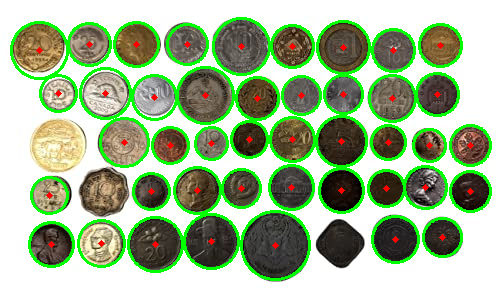

In [ ]:
cv2_imshow(img)
cv2.waitKey(0)
cv2.destroyAllWindows()